# Partie 2 — Optimisation industrielle avec PuLP

## Contexte

Dans le cadre de la transformation Industrie 4.0 d’InnoMoov, l’entreprise cherche à améliorer ses décisions de production et de gestion des ressources grâce à l’optimisation mathématique.

Après avoir présenté les concepts clés de Data Science applicables à la Supply Chain, cette partie du TP met en œuvre la bibliothèque Python PuLP afin de résoudre deux problèmes d’optimisation industrielle.

InnoMoov fabrique plusieurs produits intelligents liés à la mobilité urbaine :

- IM-Vision : module IA embarqué pour la détection d’obstacles ;
- IM-Flow : capteur IoT de mesure du trafic ;
- IM-FleetHub : boîtier de gestion de flotte intelligente.

Ces produits mobilisent différentes ressources : temps machine, composants électroniques, main-d’œuvre, énergie et capacité de contrôle qualité.

## Objectifs de cette partie

L’objectif est de construire deux modèles d’optimisation :

### 1. Maximisation des performances productives

Le premier modèle vise à déterminer les quantités optimales à produire pour maximiser la valeur productive quotidienne d’InnoMoov.

Ce problème sera formulé en programmation en nombres entiers, car l’entreprise fabrique des produits finis : il n’est pas possible de produire 0,5 module ou 0,3 boîtier.

Le modèle comportera :

- 3 variables de décision ;
- 1 fonction objectif à maximiser ;
- 5 contraintes industrielles.

### 2. Minimisation de la consommation énergétique

Le second modèle vise à réduire la consommation énergétique globale liée à la production, tout en respectant des exigences minimales de production.

Ce modèle permettra de montrer comment l’optimisation peut aider InnoMoov à produire de manière plus efficace, plus sobre et plus durable.

## Problématique

Comment InnoMoov peut-elle utiliser PuLP pour optimiser ses choix de production, améliorer ses performances industrielles et réduire ses consommations de ressources ?

---

In [1]:
# Installation de PuLP
!pip install -q pulp

# Import de PuLP
import pulp as plp

# Vérification de l'installation
print("PuLP est correctement installé et importé.")
print("Version de PuLP :", plp.__version__)

PuLP est correctement installé et importé.
Version de PuLP : 3.3.2


---

# 1. Maximisation des performances productives avec PuLP

## Objectif industriel

InnoMoov souhaite déterminer les quantités optimales à produire sur une journée afin de maximiser sa performance productive.

L’entreprise fabrique trois produits intelligents liés à la mobilité urbaine :

- **IM-Vision** : module IA embarqué pour la détection d’obstacles ;
- **IM-Flow** : capteur intelligent de mesure du trafic ;
- **IM-FleetHub** : boîtier de gestion de flotte connectée.

Le problème est formulé en **programmation en nombres entiers**, car InnoMoov fabrique des produits finis. Il n’est donc pas possible de produire une fraction de module, de capteur ou de boîtier.

## Variables de décision

On définit les variables suivantes :

- \(x_1\) : nombre de modules **IM-Vision** à produire ;
- \(x_2\) : nombre de capteurs **IM-Flow** à produire ;
- \(x_3\) : nombre de boîtiers **IM-FleetHub** à produire.

Ces trois variables sont des entiers positifs ou nuls.

## Fonction objectif

L’objectif est de maximiser la contribution productive journalière.

Pour construire le modèle, on associe à chaque produit une contribution industrielle estimée :

| Produit | Contribution unitaire estimée |
|---|---:|
| IM-Vision | 68 |
| IM-Flow | 42 |
| IM-FleetHub | 75 |

La fonction objectif est donc :

\[
\text{Maximiser } Z = 68x_1 + 42x_2 + 75x_3
\]

## Contraintes industrielles

Le modèle intègre cinq contraintes représentatives d’un atelier InnoMoov :

1. **Capacité d’assemblage et de test MES**  
   Le temps disponible sur la journée est limité à 480 minutes.

2. **Capacité de contrôle qualité**  
   Le poste qualité dispose de 180 minutes de contrôle sur la journée.

3. **Disponibilité des composants électroniques**  
   Le stock de composants disponibles est limité à 360 unités.

4. **Engagement minimal sur IM-Vision**  
   InnoMoov doit produire au moins 8 modules IM-Vision pour répondre aux commandes prioritaires.

5. **Engagement minimal sur IM-FleetHub**  
   InnoMoov doit produire au moins 5 boîtiers IM-FleetHub pour garantir la continuité des contrats de gestion de flotte.

## Intérêt du modèle

Ce modèle permet à InnoMoov de transformer une décision de production en problème d’optimisation.  
Au lieu de choisir les quantités de manière intuitive, l’entreprise utilise les données de capacité, de stock et de demande minimale pour identifier le meilleur plan de production possible.

Le résultat attendu est un plan de production journalier plus rationnel, plus rentable et mieux aligné avec les contraintes réelles de l’atelier.

In [2]:
# Modélisation d'un problème de production en nombres entiers
# Objectif : maximiser la contribution productive journalière d'InnoMoov

# Création du problème d'optimisation
production_model = plp.LpProblem(
    name="InnoMoov_Maximisation_Performance_Productive",
    sense=plp.LpMaximize
)

# Produits étudiés
products = ["IM-Vision", "IM-Flow", "IM-FleetHub"]

# Contribution productive unitaire estimée
# Cette contribution peut représenter une marge, une valeur industrielle ou un score de priorité métier
unit_contribution = {
    "IM-Vision": 68,
    "IM-Flow": 42,
    "IM-FleetHub": 75
}

# Temps d'assemblage et de test MES par unité produite, en minutes
assembly_time = {
    "IM-Vision": 18,
    "IM-Flow": 10,
    "IM-FleetHub": 22
}

# Temps de contrôle qualité par unité produite, en minutes
quality_time = {
    "IM-Vision": 6,
    "IM-Flow": 3,
    "IM-FleetHub": 8
}

# Nombre de composants électroniques nécessaires par unité produite
components_required = {
    "IM-Vision": 9,
    "IM-Flow": 5,
    "IM-FleetHub": 12
}

# Variables de décision entières : quantités journalières à produire
production_qty = {
    product: plp.LpVariable(
        name=f"qty_{product.replace('-', '_')}",
        lowBound=0,
        cat="Integer"
    )
    for product in products
}

# Fonction objectif : maximisation de la contribution productive totale
production_model += plp.lpSum(
    unit_contribution[product] * production_qty[product]
    for product in products
), "Total_Productive_Contribution"

# Contrainte 1 : capacité journalière d'assemblage et de test MES
production_model += plp.lpSum(
    assembly_time[product] * production_qty[product]
    for product in products
) <= 480, "Assembly_Test_Capacity"

# Contrainte 2 : capacité journalière du contrôle qualité
production_model += plp.lpSum(
    quality_time[product] * production_qty[product]
    for product in products
) <= 180, "Quality_Control_Capacity"

# Contrainte 3 : disponibilité des composants électroniques
production_model += plp.lpSum(
    components_required[product] * production_qty[product]
    for product in products
) <= 360, "Electronic_Components_Availability"

# Contrainte 4 : production minimale de modules IM-Vision
production_model += production_qty["IM-Vision"] >= 8, "Minimum_IM_Vision_Commitment"

# Contrainte 5 : production minimale de boîtiers IM-FleetHub
production_model += production_qty["IM-FleetHub"] >= 5, "Minimum_IM_FleetHub_Commitment"

# Résolution du modèle
status = production_model.solve(plp.PULP_CBC_CMD(msg=False))

# Restitution synthétique des résultats
print("Statut du modèle :", plp.LpStatus[status])
print("\nPlan de production optimal :")

for product in products:
    print(f"- {product} : {int(plp.value(production_qty[product]))} unités")

print("\nContribution productive maximale :", round(plp.value(production_model.objective), 2))

# Analyse de l'utilisation des ressources critiques
used_assembly_time = sum(
    assembly_time[product] * plp.value(production_qty[product])
    for product in products
)

used_quality_time = sum(
    quality_time[product] * plp.value(production_qty[product])
    for product in products
)

used_components = sum(
    components_required[product] * plp.value(production_qty[product])
    for product in products
)

print("\nUtilisation des ressources :")
print(f"- Assemblage et tests MES : {used_assembly_time:.0f} / 480 minutes")
print(f"- Contrôle qualité : {used_quality_time:.0f} / 180 minutes")
print(f"- Composants électroniques : {used_components:.0f} / 360 composants")

Statut du modèle : Optimal

Plan de production optimal :
- IM-Vision : 10 unités
- IM-Flow : 19 unités
- IM-FleetHub : 5 unités

Contribution productive maximale : 1853.0

Utilisation des ressources :
- Assemblage et tests MES : 480 / 480 minutes
- Contrôle qualité : 157 / 180 minutes
- Composants électroniques : 245 / 360 composants


## Interprétation des résultats de maximisation

Le modèle d’optimisation retourne un statut **Optimal**, ce qui signifie qu’une solution réalisable et maximale a été identifiée par PuLP.

Le plan de production optimal est le suivant :

| Produit | Quantité optimale |
|---|---:|
| IM-Vision | 10 unités |
| IM-Flow | 19 unités |
| IM-FleetHub | 5 unités |

La contribution productive maximale obtenue est de **1853 points de contribution**.

### Analyse industrielle

Le modèle recommande de produire principalement des capteurs **IM-Flow**, car ils consomment peu de temps d’assemblage et de contrôle qualité par rapport à leur contribution productive. Cela permet d’augmenter le volume global tout en respectant les limites de capacité.

La production de **IM-Vision** est supérieure au minimum imposé, ce qui montre que ce produit reste intéressant dans le mix de production. En revanche, **IM-FleetHub** reste au niveau minimal requis, car il consomme davantage de ressources, notamment en temps d’assemblage, en contrôle qualité et en composants électroniques.

### Analyse des ressources

| Ressource | Utilisation | Capacité | Taux d’utilisation |
|---|---:|---:|---:|
| Assemblage et tests MES | 480 min | 480 min | 100 % |
| Contrôle qualité | 157 min | 180 min | 87,2 % |
| Composants électroniques | 245 | 360 | 68,1 % |

La contrainte la plus critique est donc la capacité d’**assemblage et de tests MES**, utilisée à **100 %**.  
Cela signifie que l’atelier atteint sa limite opérationnelle sur cette ressource.

### Bénéfices pour InnoMoov

Ce modèle permet à InnoMoov de :

- déterminer automatiquement le meilleur mix de production ;
- respecter les engagements clients prioritaires ;
- éviter une surcharge des ressources industrielles ;
- identifier la ressource bloquante de l’atelier ;
- améliorer la coordination entre production, qualité, stock et planification.

L’optimisation met en évidence un point important : pour produire davantage, InnoMoov devra prioritairement agir sur la capacité d’assemblage et de tests MES, par exemple en réduisant les temps de cycle, en ajoutant un poste de test ou en automatisant davantage certaines opérations.

,Produit,Quantité optimale,Contribution unitaire,Contribution totale
0,IM-Vision,10,68,680
1,IM-Flow,19,42,798
2,IM-FleetHub,5,75,375


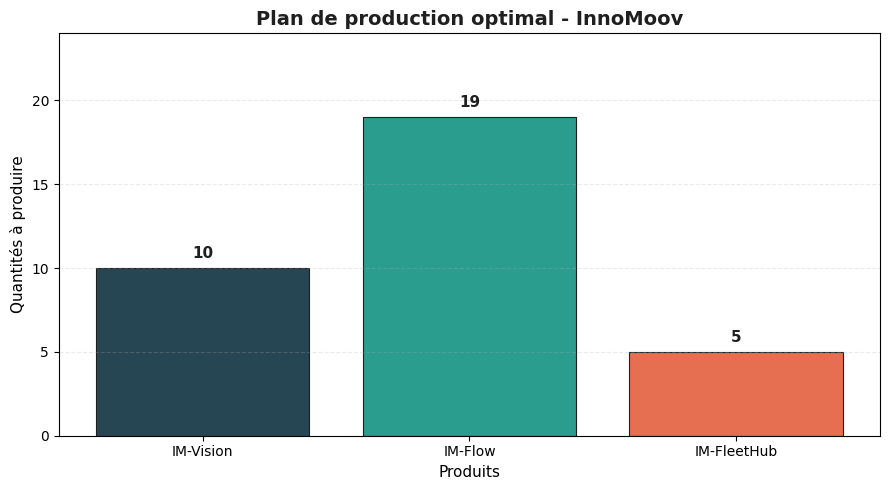

,Ressource,Utilisé,Capacité,Taux d'utilisation (%),Marge restante
0,Assemblage & tests MES,480.0,480,100.0,0.0
1,Contrôle qualité,157.0,180,87.2,23.0
2,Composants électroniques,245.0,360,68.1,115.0


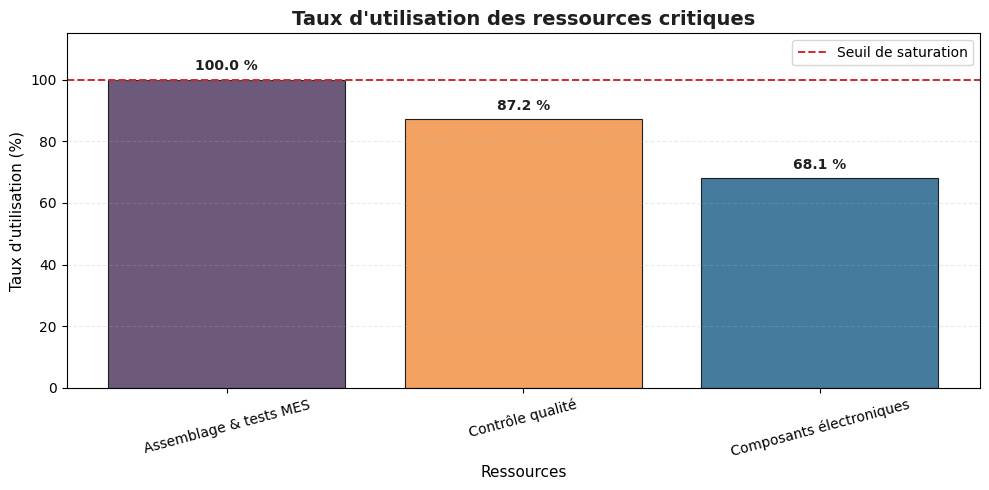

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------------------------------------------------
# Consolidation des résultats du solveur dans une structure exploitable
# -------------------------------------------------------------------

production_results = pd.DataFrame({
    "Produit": products,
    "Quantité optimale": [
        int(plp.value(production_qty[product])) for product in products
    ],
    "Contribution unitaire": [
        unit_contribution[product] for product in products
    ]
})

production_results["Contribution totale"] = (
    production_results["Quantité optimale"] * production_results["Contribution unitaire"]
)

display(production_results)

# -------------------------------------------------------------------
# Palette visuelle InnoMoov : sobre, technologique et différenciante
# -------------------------------------------------------------------

product_colors = {
    "IM-Vision": "#264653",    # bleu pétrole industriel
    "IM-Flow": "#2A9D8F",      # vert technologique
    "IM-FleetHub": "#E76F51"   # corail dynamique
}

resource_colors = {
    "Assemblage & tests MES": "#6D597A",        # violet industriel
    "Contrôle qualité": "#F4A261",              # orange doux
    "Composants électroniques": "#457B9D"       # bleu technique
}

# -------------------------------------------------------------------
# Visualisation du mix de production optimal
# -------------------------------------------------------------------

plt.figure(figsize=(9, 5))

bars = plt.bar(
    production_results["Produit"],
    production_results["Quantité optimale"],
    color=[product_colors[product] for product in production_results["Produit"]],
    edgecolor="#1F1F1F",
    linewidth=0.8
)

plt.title(
    "Plan de production optimal - InnoMoov",
    fontsize=14,
    fontweight="bold",
    color="#1F1F1F"
)

plt.xlabel("Produits", fontsize=11)
plt.ylabel("Quantités à produire", fontsize=11)
plt.grid(axis="y", alpha=0.25, linestyle="--")

# Affichage des valeurs au-dessus des barres
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.4,
        f"{int(height)}",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold",
        color="#1F1F1F"
    )

plt.ylim(0, production_results["Quantité optimale"].max() + 5)
plt.tight_layout()
plt.show()

# -------------------------------------------------------------------
# Analyse de charge des ressources critiques
# -------------------------------------------------------------------

resource_usage = pd.DataFrame({
    "Ressource": [
        "Assemblage & tests MES",
        "Contrôle qualité",
        "Composants électroniques"
    ],
    "Utilisé": [
        used_assembly_time,
        used_quality_time,
        used_components
    ],
    "Capacité": [
        480,
        180,
        360
    ]
})

resource_usage["Taux d'utilisation (%)"] = (
    resource_usage["Utilisé"] / resource_usage["Capacité"] * 100
).round(1)

resource_usage["Marge restante"] = (
    resource_usage["Capacité"] - resource_usage["Utilisé"]
)

display(resource_usage)

# -------------------------------------------------------------------
# Visualisation du taux d'utilisation des ressources critiques
# -------------------------------------------------------------------

plt.figure(figsize=(10, 5))

bars = plt.bar(
    resource_usage["Ressource"],
    resource_usage["Taux d'utilisation (%)"],
    color=[resource_colors[resource] for resource in resource_usage["Ressource"]],
    edgecolor="#1F1F1F",
    linewidth=0.8
)

# Ligne de saturation à 100 %
plt.axhline(
    100,
    color="#D62828",
    linestyle="--",
    linewidth=1.4,
    label="Seuil de saturation"
)

plt.title(
    "Taux d'utilisation des ressources critiques",
    fontsize=14,
    fontweight="bold",
    color="#1F1F1F"
)

plt.xlabel("Ressources", fontsize=11)
plt.ylabel("Taux d'utilisation (%)", fontsize=11)
plt.ylim(0, 115)
plt.grid(axis="y", alpha=0.25, linestyle="--")
plt.xticks(rotation=15)

# Affichage des taux au-dessus des barres
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 2,
        f"{height:.1f} %",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
        color="#1F1F1F"
    )

plt.legend()
plt.tight_layout()
plt.show()

## Visualisation de la zone réalisable du modèle de maximisation

Le graphique précédent présente le plan optimal et l’utilisation des ressources critiques.

Une visualisation de la **zone réalisable** du modèle de maximisation.

Le modèle InnoMoov comporte trois variables de décision :

- \(x_1\) : quantité de **IM-Vision** ;
- \(x_2\) : quantité de **IM-Flow** ;
- \(x_3\) : quantité de **IM-FleetHub**.

Comme un graphique 2D ne peut pas représenter directement trois variables, on réalise une projection du problème en fixant :

\[
x_3 = 5
\]

Cette valeur correspond à la quantité optimale de **IM-FleetHub** trouvée par le solveur PuLP.

Le graphique représente donc une coupe du problème entre **IM-Vision** et **IM-Flow**, avec les contraintes industrielles, la zone réalisable, les combinaisons entières possibles et la solution optimale.

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Projection 2D du modèle de maximisation productive
# IM-FleetHub est fixé à sa valeur optimale afin de visualiser le problème en 2D

fixed_fleethub_qty = int(plp.value(production_qty["IM-FleetHub"]))

optimal_im_vision = int(plp.value(production_qty["IM-Vision"]))
optimal_im_flow = int(plp.value(production_qty["IM-Flow"]))

print("Valeur fixée pour IM-FleetHub :", fixed_fleethub_qty)
print("Solution optimale projetée :")
print("- IM-Vision :", optimal_im_vision)
print("- IM-Flow :", optimal_im_flow)

Valeur fixée pour IM-FleetHub : 5
Solution optimale projetée :
- IM-Vision : 10
- IM-Flow : 19


In [7]:
# Domaine d'analyse pour IM-Vision
x_vals = np.linspace(0, 30, 300)

# Contraintes projetées sur le plan IM-Vision / IM-Flow
assembly_constraint = (
    480
    - assembly_time["IM-FleetHub"] * fixed_fleethub_qty
    - assembly_time["IM-Vision"] * x_vals
) / assembly_time["IM-Flow"]

quality_constraint = (
    180
    - quality_time["IM-FleetHub"] * fixed_fleethub_qty
    - quality_time["IM-Vision"] * x_vals
) / quality_time["IM-Flow"]

components_constraint = (
    360
    - components_required["IM-FleetHub"] * fixed_fleethub_qty
    - components_required["IM-Vision"] * x_vals
) / components_required["IM-Flow"]

# La zone réalisable est limitée par la contrainte la plus restrictive
upper_bound = np.minimum.reduce([
    assembly_constraint,
    quality_constraint,
    components_constraint
])

# Les valeurs négatives ne sont pas admissibles
upper_bound = np.maximum(upper_bound, 0)

print("Contraintes projetées calculées avec succès.")

Contraintes projetées calculées avec succès.


In [8]:
# Identification des combinaisons entières réalisables
# Cette étape rappelle la logique Integer Programming du cours

integer_x = []
integer_y = []

for x in range(0, 31):
    for y in range(0, 41):
        is_feasible = (
            x >= 8
            and 18 * x + 10 * y + 22 * fixed_fleethub_qty <= 480
            and 6 * x + 3 * y + 8 * fixed_fleethub_qty <= 180
            and 9 * x + 5 * y + 12 * fixed_fleethub_qty <= 360
            and y >= 0
        )
        
        if is_feasible:
            integer_x.append(x)
            integer_y.append(y)

print("Nombre de combinaisons entières réalisables :", len(integer_x))

Nombre de combinaisons entières réalisables : 161


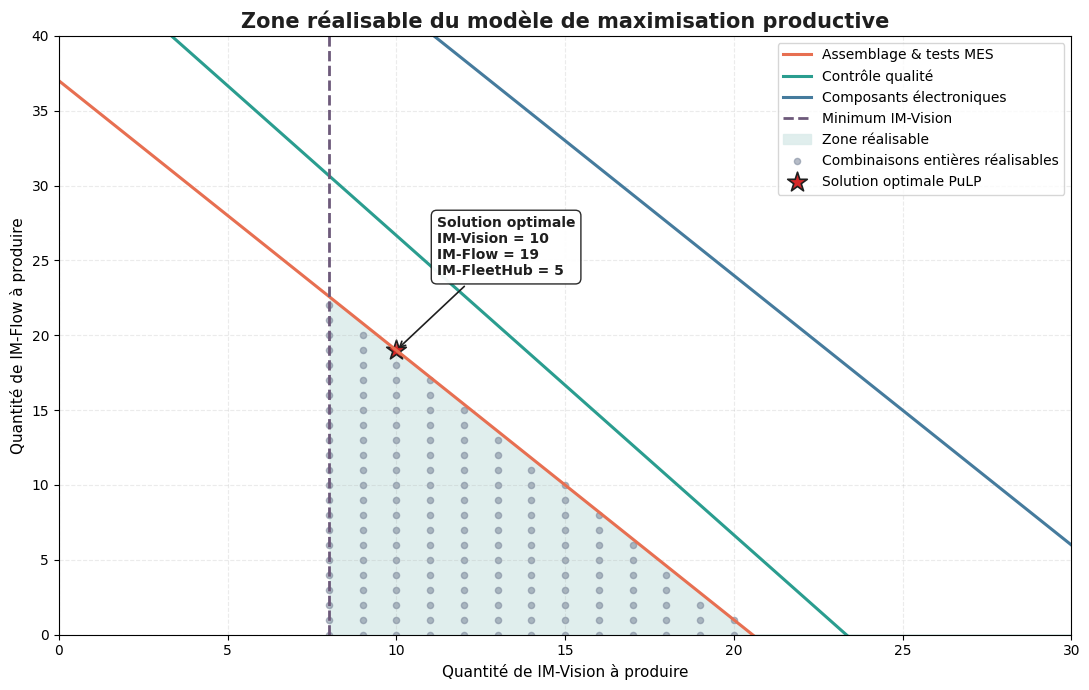

In [9]:
# Visualisation façon cours : contraintes, zone réalisable et solution optimale

feasible_mask = x_vals >= 8

plt.figure(figsize=(11, 7))

# Courbes des contraintes
plt.plot(
    x_vals,
    assembly_constraint,
    color="#E76F51",
    linewidth=2.2,
    label="Assemblage & tests MES"
)

plt.plot(
    x_vals,
    quality_constraint,
    color="#2A9D8F",
    linewidth=2.2,
    label="Contrôle qualité"
)

plt.plot(
    x_vals,
    components_constraint,
    color="#457B9D",
    linewidth=2.2,
    label="Composants électroniques"
)

# Contrainte minimale sur IM-Vision
plt.axvline(
    x=8,
    color="#6D597A",
    linestyle="--",
    linewidth=2,
    label="Minimum IM-Vision"
)

# Zone réalisable
plt.fill_between(
    x_vals[feasible_mask],
    0,
    upper_bound[feasible_mask],
    color="#DDEDEB",
    alpha=0.9,
    label="Zone réalisable"
)

# Points entiers réalisables
plt.scatter(
    integer_x,
    integer_y,
    color="#7A869A",
    s=20,
    alpha=0.55,
    label="Combinaisons entières réalisables"
)

# Solution optimale
plt.scatter(
    optimal_im_vision,
    optimal_im_flow,
    color="#D62828",
    s=220,
    marker="*",
    edgecolor="#1F1F1F",
    linewidth=1.2,
    label="Solution optimale PuLP"
)

# Annotation de la solution optimale
plt.annotate(
    f"Solution optimale\nIM-Vision = {optimal_im_vision}\nIM-Flow = {optimal_im_flow}\nIM-FleetHub = {fixed_fleethub_qty}",
    xy=(optimal_im_vision, optimal_im_flow),
    xytext=(optimal_im_vision + 1.2, optimal_im_flow + 5),
    arrowprops=dict(
        arrowstyle="->",
        color="#1F1F1F",
        linewidth=1.2
    ),
    fontsize=10,
    fontweight="bold",
    color="#1F1F1F",
    bbox=dict(
        boxstyle="round,pad=0.4",
        fc="white",
        ec="#1F1F1F",
        alpha=0.95
    )
)

plt.title(
    "Zone réalisable du modèle de maximisation productive",
    fontsize=15,
    fontweight="bold",
    color="#1F1F1F"
)

plt.xlabel("Quantité de IM-Vision à produire", fontsize=11)
plt.ylabel("Quantité de IM-Flow à produire", fontsize=11)

plt.xlim(0, 30)
plt.ylim(0, 40)

plt.grid(alpha=0.25, linestyle="--")
plt.legend(loc="upper right", frameon=True)

plt.tight_layout()
plt.show()

Ce graphique permet de visualiser la zone des solutions admissibles du modèle de maximisation productive.

Comme le modèle complet contient trois variables, la représentation est projetée en deux dimensions en fixant **IM-FleetHub = 5**, qui correspond à la quantité optimale obtenue par PuLP.

La zone bleutée représente l’ensemble des combinaisons réalisables entre **IM-Vision** et **IM-Flow**.  
Les points gris correspondent aux combinaisons entières possibles, ce qui est cohérent avec la logique de programmation en nombres entiers.

La solution optimale est située au point :

\[
IM\text{-}Vision = 10,\quad IM\text{-}Flow = 19,\quad IM\text{-}FleetHub = 5
\]

Cette solution est placée sur la frontière de la contrainte **Assemblage & tests MES**, ce qui confirme que cette ressource est le principal goulot d’étranglement du modèle.

D’un point de vue industriel, cela signifie qu’InnoMoov utilise pleinement sa capacité d’assemblage et de tests pour maximiser sa contribution productive.  
Pour augmenter davantage la production, l’entreprise devrait donc agir prioritairement sur cette ressource : réduction des temps de cycle, ajout d’un poste de test, automatisation ou meilleure planification MES.

---

# 2. Minimisation de la consommation énergétique avec PuLP

## Objectif industriel

Après avoir maximisé la performance productive, InnoMoov cherche maintenant à réduire la consommation énergétique de son atelier tout en respectant un niveau minimal de production.

Cette approche s’inscrit dans une logique de **Supply Chain 4.0 durable**, où l’objectif n’est pas seulement de produire plus, mais aussi de produire mieux : avec moins d’énergie, moins de gaspillage et une meilleure utilisation des ressources industrielles.

Dans ce modèle, InnoMoov fabrique toujours trois produits :

* **IM-Vision** : module IA embarqué pour la détection d’obstacles ;
* **IM-Flow** : capteur intelligent de mesure du trafic ;
* **IM-FleetHub** : boîtier de gestion de flotte connectée.

## Variables de décision

On définit les variables suivantes :

* (x_1) : nombre de modules **IM-Vision** à produire ;
* (x_2) : nombre de capteurs **IM-Flow** à produire ;
* (x_3) : nombre de boîtiers **IM-FleetHub** à produire.

Ces variables sont des entiers positifs ou nuls, car InnoMoov fabrique des produits finis.

## Fonction objectif

L’objectif est de minimiser la consommation énergétique totale de production.

| Produit     | Consommation énergétique unitaire estimée |
| ----------- | ----------------------------------------: |
| IM-Vision   |                                   4,8 kWh |
| IM-Flow     |                                   2,6 kWh |
| IM-FleetHub |                                   5,5 kWh |

La fonction objectif est donc :

[
\text{Minimiser } E = 4,8x_1 + 2,6x_2 + 5,5x_3
]

## Contraintes industrielles

Le modèle doit respecter plusieurs contraintes réalistes :

1. Produire au moins **8 modules IM-Vision** pour répondre aux commandes prioritaires.
2. Produire au moins **12 capteurs IM-Flow** pour alimenter les projets de mesure du trafic.
3. Produire au moins **5 boîtiers IM-FleetHub** pour maintenir les contrats de gestion de flotte.
4. Produire au moins **30 unités au total** pour garantir un volume journalier minimal.
5. Ne pas dépasser **480 minutes** d’assemblage et de tests MES sur la journée.

## Intérêt du modèle

Ce modèle permet à InnoMoov de trouver le plan de production le moins énergivore tout en respectant les engagements clients et les contraintes de capacité de l’atelier.

L’objectif est de montrer que l’optimisation mathématique peut aider l’entreprise à concilier performance industrielle, sobriété énergétique et durabilité.


In [4]:
# Modélisation d'un problème de production sobre en énergie
# Objectif : minimiser la consommation énergétique tout en respectant les engagements industriels

energy_model = plp.LpProblem(
    name="InnoMoov_Minimisation_Consommation_Energetique",
    sense=plp.LpMinimize
)

# Portefeuille de produits InnoMoov étudié
products = ["IM-Vision", "IM-Flow", "IM-FleetHub"]

# Consommation énergétique unitaire estimée, en kWh par unité produite
unit_energy_consumption = {
    "IM-Vision": 4.8,
    "IM-Flow": 2.6,
    "IM-FleetHub": 5.5
}

# Temps d'assemblage et de test MES par unité produite, en minutes
assembly_time = {
    "IM-Vision": 18,
    "IM-Flow": 10,
    "IM-FleetHub": 22
}

# Variables de décision entières : quantités journalières à produire
energy_qty = {
    product: plp.LpVariable(
        name=f"energy_qty_{product.replace('-', '_')}",
        lowBound=0,
        cat="Integer"
    )
    for product in products
}

# Fonction objectif : minimisation de la consommation énergétique totale
energy_model += plp.lpSum(
    unit_energy_consumption[product] * energy_qty[product]
    for product in products
), "Total_Energy_Consumption"

# Engagement minimal sur les modules IM-Vision
energy_model += energy_qty["IM-Vision"] >= 8, "Minimum_IM_Vision_Demand"

# Engagement minimal sur les capteurs IM-Flow
energy_model += energy_qty["IM-Flow"] >= 12, "Minimum_IM_Flow_Demand"

# Engagement minimal sur les boîtiers IM-FleetHub
energy_model += energy_qty["IM-FleetHub"] >= 5, "Minimum_IM_FleetHub_Demand"

# Volume journalier minimal afin de garantir une production suffisante
energy_model += plp.lpSum(
    energy_qty[product]
    for product in products
) >= 30, "Minimum_Total_Daily_Output"

# Capacité maximale d'assemblage et de tests MES sur la journée
energy_model += plp.lpSum(
    assembly_time[product] * energy_qty[product]
    for product in products
) <= 480, "Assembly_Test_Capacity"

# Résolution du modèle
status = energy_model.solve(plp.PULP_CBC_CMD(msg=False))

# Restitution des résultats
print("Statut du modèle :", plp.LpStatus[status])
print("\nPlan de production minimisant la consommation énergétique :")

for product in products:
    print(f"- {product} : {int(plp.value(energy_qty[product]))} unités")

print("\nConsommation énergétique minimale :", round(plp.value(energy_model.objective), 2), "kWh")

# Analyse des ressources et indicateurs énergétiques
total_units = sum(
    plp.value(energy_qty[product])
    for product in products
)

used_assembly_time_energy = sum(
    assembly_time[product] * plp.value(energy_qty[product])
    for product in products
)

average_energy_per_unit = (
    plp.value(energy_model.objective) / total_units
)

print("\nIndicateurs complémentaires :")
print(f"- Volume total produit : {total_units:.0f} unités")
print(f"- Assemblage et tests MES : {used_assembly_time_energy:.0f} / 480 minutes")
print(f"- Consommation moyenne par unité : {average_energy_per_unit:.2f} kWh/unité")

Statut du modèle : Optimal

Plan de production minimisant la consommation énergétique :
- IM-Vision : 8 unités
- IM-Flow : 17 unités
- IM-FleetHub : 5 unités

Consommation énergétique minimale : 110.1 kWh

Indicateurs complémentaires :
- Volume total produit : 30 unités
- Assemblage et tests MES : 424 / 480 minutes
- Consommation moyenne par unité : 3.67 kWh/unité


## Interprétation des résultats de minimisation énergétique

Le modèle retourne un statut **Optimal**, ce qui signifie qu’il existe une solution réalisable minimisant la consommation énergétique tout en respectant l’ensemble des contraintes industrielles.

Le plan de production optimal est le suivant :

| Produit | Quantité optimale |
|---|---:|
| IM-Vision | 8 unités |
| IM-Flow | 17 unités |
| IM-FleetHub | 5 unités |

La consommation énergétique totale minimale obtenue est de **110,1 kWh**.

### Analyse industrielle

Le modèle choisit de produire exactement les quantités minimales imposées pour **IM-Vision** et **IM-FleetHub**, car ce sont les produits les plus consommateurs d’énergie par unité.

En revanche, il augmente la production de **IM-Flow** jusqu’à 17 unités. Ce choix est rationnel, car **IM-Flow** est le produit le moins énergivore du portefeuille. Il permet donc d’atteindre le volume journalier minimal de 30 unités avec la consommation énergétique la plus faible possible.

### Analyse des ressources

| Indicateur | Valeur |
|---|---:|
| Volume total produit | 30 unités |
| Assemblage et tests MES | 424 / 480 min |
| Consommation moyenne par unité | 3,67 kWh/unité |

Le temps d’assemblage et de tests reste inférieur à la capacité maximale, avec une marge de **56 minutes**.  
Cela montre que la limitation principale de ce modèle n’est pas la capacité atelier, mais la recherche du mix de production le plus sobre en énergie.

### Bénéfices pour InnoMoov

Ce modèle permet à InnoMoov de :

- réduire la consommation énergétique globale de l’atelier ;
- respecter les engagements de production minimum ;
- privilégier les produits les plus efficients sur le plan énergétique ;
- intégrer la durabilité dans les décisions de planification ;
- mieux concilier performance industrielle et sobriété énergétique.

Cette approche s’inscrit pleinement dans une logique **Industrie 4.0 durable**, où les décisions de production ne sont plus seulement orientées vers le volume ou la marge, mais aussi vers l’optimisation des ressources et la réduction de l’empreinte énergétique.

,Produit,Quantité optimale,Consommation unitaire (kWh),Consommation totale (kWh)
0,IM-Vision,8,4.8,38.4
1,IM-Flow,17,2.6,44.2
2,IM-FleetHub,5,5.5,27.5


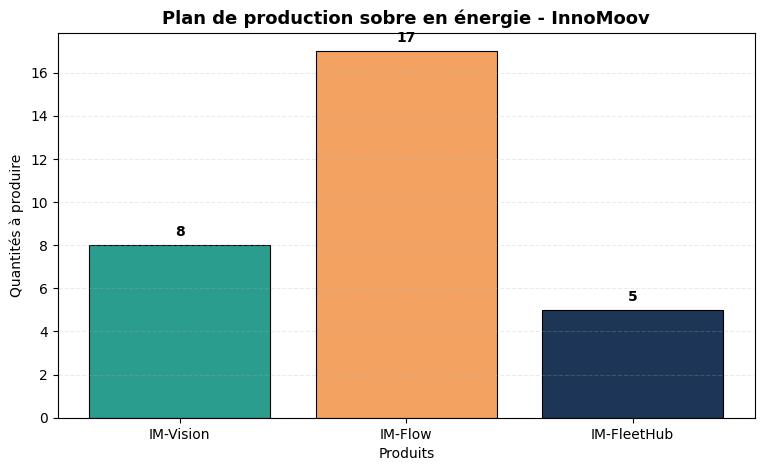

,Indicateur,Valeur,Unité
0,Consommation énergétique totale,110.10,kWh
1,Volume total produit,30.00,unités
2,Assemblage & tests MES utilisés,424.00,minutes
3,Assemblage & tests MES disponibles,480.00,minutes
4,Marge de capacité restante,56.00,minutes
5,Consommation moyenne par unité,3.67,kWh/unité


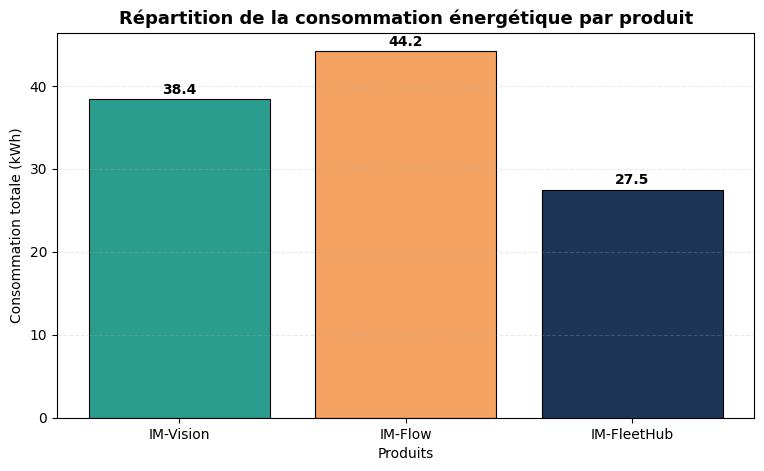

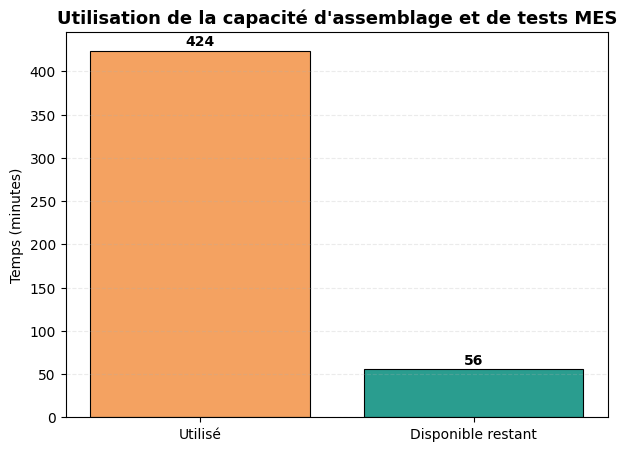

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# -------------------------------------------------------------------
# Consolidation des résultats du modèle de minimisation énergétique
# -------------------------------------------------------------------

energy_results = pd.DataFrame({
    "Produit": products,
    "Quantité optimale": [
        int(plp.value(energy_qty[product])) for product in products
    ],
    "Consommation unitaire (kWh)": [
        unit_energy_consumption[product] for product in products
    ]
})

energy_results["Consommation totale (kWh)"] = (
    energy_results["Quantité optimale"] * energy_results["Consommation unitaire (kWh)"]
)

display(energy_results)

# -------------------------------------------------------------------
# Palette graphique cohérente avec l'identité visuelle InnoMoov
# -------------------------------------------------------------------

palette_innomoov = {
    "IM-Vision": "#2A9D8F",    # vert/teal
    "IM-Flow": "#F4A261",      # orange doux
    "IM-FleetHub": "#1D3557"   # bleu nuit
}

bar_colors = [palette_innomoov[product] for product in energy_results["Produit"]]

# -------------------------------------------------------------------
# Graphique 1 - Plan de production minimisant la consommation énergétique
# -------------------------------------------------------------------

plt.figure(figsize=(9, 5))
bars = plt.bar(
    energy_results["Produit"],
    energy_results["Quantité optimale"],
    color=bar_colors,
    edgecolor="black",
    linewidth=0.8
)

plt.title("Plan de production sobre en énergie - InnoMoov", fontsize=13, fontweight="bold")
plt.xlabel("Produits")
plt.ylabel("Quantités à produire")
plt.grid(axis="y", alpha=0.25, linestyle="--")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.3,
        f"{int(height)}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

plt.show()

# -------------------------------------------------------------------
# Analyse détaillée de la consommation énergétique
# -------------------------------------------------------------------

total_energy = plp.value(energy_model.objective)

energy_indicators = pd.DataFrame({
    "Indicateur": [
        "Consommation énergétique totale",
        "Volume total produit",
        "Assemblage & tests MES utilisés",
        "Assemblage & tests MES disponibles",
        "Marge de capacité restante",
        "Consommation moyenne par unité"
    ],
    "Valeur": [
        round(total_energy, 2),
        int(total_units),
        round(used_assembly_time_energy, 0),
        480,
        round(480 - used_assembly_time_energy, 0),
        round(average_energy_per_unit, 2)
    ],
    "Unité": [
        "kWh",
        "unités",
        "minutes",
        "minutes",
        "minutes",
        "kWh/unité"
    ]
})

display(energy_indicators)

# -------------------------------------------------------------------
# Graphique 2 - Consommation énergétique totale par produit
# -------------------------------------------------------------------

plt.figure(figsize=(9, 5))
bars = plt.bar(
    energy_results["Produit"],
    energy_results["Consommation totale (kWh)"],
    color=bar_colors,
    edgecolor="black",
    linewidth=0.8
)

plt.title("Répartition de la consommation énergétique par produit", fontsize=13, fontweight="bold")
plt.xlabel("Produits")
plt.ylabel("Consommation totale (kWh)")
plt.grid(axis="y", alpha=0.25, linestyle="--")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.3,
        f"{height:.1f}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

plt.show()

# -------------------------------------------------------------------
# Graphique 3 - Utilisation de la capacité atelier
# -------------------------------------------------------------------

capacity_labels = ["Utilisé", "Disponible restant"]
capacity_values = [used_assembly_time_energy, 480 - used_assembly_time_energy]
capacity_colors = ["#F4A261", "#2A9D8F"]

plt.figure(figsize=(7, 5))
bars = plt.bar(
    capacity_labels,
    capacity_values,
    color=capacity_colors,
    edgecolor="black",
    linewidth=0.8
)

plt.title("Utilisation de la capacité d'assemblage et de tests MES", fontsize=13, fontweight="bold")
plt.ylabel("Temps (minutes)")
plt.grid(axis="y", alpha=0.25, linestyle="--")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 2,
        f"{height:.0f}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

plt.show()

## Visualisation de la zone réalisable du modèle de minimisation énergétique

On ajoute une visualisation graphique du modèle de minimisation énergétique.

Le modèle complet contient trois variables de décision :

- \(x_1\) : quantité de **IM-Vision** ;
- \(x_2\) : quantité de **IM-Flow** ;
- \(x_3\) : quantité de **IM-FleetHub**.

Comme pour le modèle précédent, un graphique en deux dimensions ne peut pas représenter directement les trois variables.  
On fixe donc :

\[
x_3 = 5
\]

Cette valeur correspond à la quantité optimale de **IM-FleetHub** obtenue dans le modèle de minimisation énergétique.

Le graphique représente une projection entre **IM-Vision** et **IM-Flow**, avec :

- les contraintes minimales de production ;
- la contrainte de volume total minimal ;
- la contrainte de capacité d’assemblage et de tests MES ;
- la zone réalisable ;
- les combinaisons entières possibles ;
- la solution optimale minimisant la consommation énergétique.

Valeur fixée pour IM-FleetHub : 5
Solution optimale projetée :
- IM-Vision : 8
- IM-Flow : 17
Nombre de combinaisons entières réalisables : 25


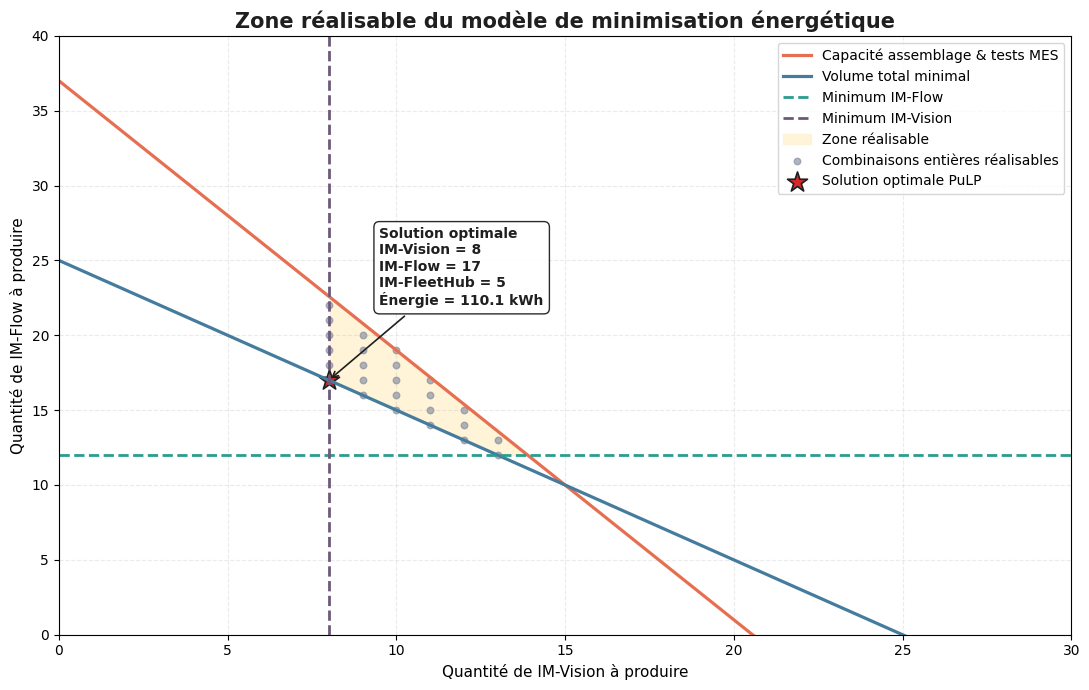

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------------------------------------------
# Projection 2D du modèle de minimisation énergétique
# Hypothèse de visualisation : IM-FleetHub fixé à sa valeur optimale
# -------------------------------------------------------------------

fixed_fleethub_qty_energy = int(plp.value(energy_qty["IM-FleetHub"]))

optimal_im_vision_energy = int(plp.value(energy_qty["IM-Vision"]))
optimal_im_flow_energy = int(plp.value(energy_qty["IM-Flow"]))

print("Valeur fixée pour IM-FleetHub :", fixed_fleethub_qty_energy)
print("Solution optimale projetée :")
print("- IM-Vision :", optimal_im_vision_energy)
print("- IM-Flow :", optimal_im_flow_energy)

# Domaine d'analyse pour IM-Vision
x_vals_energy = np.linspace(0, 30, 300)

# -------------------------------------------------------------------
# Contraintes projetées sur le plan IM-Vision / IM-Flow
# -------------------------------------------------------------------

# Contrainte de capacité MES :
# 18*x1 + 10*x2 + 22*x3 <= 480
assembly_constraint_energy = (
    480
    - assembly_time["IM-FleetHub"] * fixed_fleethub_qty_energy
    - assembly_time["IM-Vision"] * x_vals_energy
) / assembly_time["IM-Flow"]

# Contrainte de volume total minimal :
# x1 + x2 + x3 >= 30
# donc x2 >= 30 - x3 - x1
minimum_total_output_constraint = (
    30
    - fixed_fleethub_qty_energy
    - x_vals_energy
)

# Contraintes minimales de production
minimum_im_vision = 8
minimum_im_flow = 12

# -------------------------------------------------------------------
# Identification des combinaisons entières réalisables
# -------------------------------------------------------------------

integer_x_energy = []
integer_y_energy = []

for x in range(0, 31):
    for y in range(0, 41):
        is_feasible = (
            x >= minimum_im_vision
            and y >= minimum_im_flow
            and fixed_fleethub_qty_energy >= 5
            and x + y + fixed_fleethub_qty_energy >= 30
            and 18 * x + 10 * y + 22 * fixed_fleethub_qty_energy <= 480
        )
        
        if is_feasible:
            integer_x_energy.append(x)
            integer_y_energy.append(y)

print("Nombre de combinaisons entières réalisables :", len(integer_x_energy))

# -------------------------------------------------------------------
# Construction de la zone réalisable
# -------------------------------------------------------------------

# Pour chaque valeur de IM-Vision, la borne basse de IM-Flow est imposée par :
# - le minimum IM-Flow
# - le volume total minimal
lower_bound_energy = np.maximum(
    minimum_im_flow,
    minimum_total_output_constraint
)

# La borne haute de IM-Flow est imposée par la capacité MES
upper_bound_energy = assembly_constraint_energy

# La zone est réalisable uniquement si :
# - IM-Vision respecte son minimum
# - la borne haute est supérieure à la borne basse
feasible_mask_energy = (
    (x_vals_energy >= minimum_im_vision)
    & (upper_bound_energy >= lower_bound_energy)
)

# -------------------------------------------------------------------
# Visualisation : contraintes, zone réalisable, optimum
# -------------------------------------------------------------------

plt.figure(figsize=(11, 7))

# Contrainte capacité MES
plt.plot(
    x_vals_energy,
    assembly_constraint_energy,
    color="#E76F51",
    linewidth=2.3,
    label="Capacité assemblage & tests MES"
)

# Contrainte volume total minimal
plt.plot(
    x_vals_energy,
    minimum_total_output_constraint,
    color="#457B9D",
    linewidth=2.3,
    label="Volume total minimal"
)

# Minimum IM-Flow
plt.axhline(
    y=minimum_im_flow,
    color="#2A9D8F",
    linestyle="--",
    linewidth=2,
    label="Minimum IM-Flow"
)

# Minimum IM-Vision
plt.axvline(
    x=minimum_im_vision,
    color="#6D597A",
    linestyle="--",
    linewidth=2,
    label="Minimum IM-Vision"
)

# Zone réalisable
plt.fill_between(
    x_vals_energy[feasible_mask_energy],
    lower_bound_energy[feasible_mask_energy],
    upper_bound_energy[feasible_mask_energy],
    color="#FFF3D6",
    alpha=0.95,
    label="Zone réalisable"
)

# Combinaisons entières réalisables
plt.scatter(
    integer_x_energy,
    integer_y_energy,
    color="#7A869A",
    s=22,
    alpha=0.6,
    label="Combinaisons entières réalisables"
)

# Solution optimale
plt.scatter(
    optimal_im_vision_energy,
    optimal_im_flow_energy,
    color="#D62828",
    s=230,
    marker="*",
    edgecolor="#1F1F1F",
    linewidth=1.2,
    label="Solution optimale PuLP"
)

# Annotation de la solution optimale
plt.annotate(
    f"Solution optimale\nIM-Vision = {optimal_im_vision_energy}\nIM-Flow = {optimal_im_flow_energy}\nIM-FleetHub = {fixed_fleethub_qty_energy}\nÉnergie = {plp.value(energy_model.objective):.1f} kWh",
    xy=(optimal_im_vision_energy, optimal_im_flow_energy),
    xytext=(optimal_im_vision_energy + 1.5, optimal_im_flow_energy + 5),
    arrowprops=dict(
        arrowstyle="->",
        color="#1F1F1F",
        linewidth=1.2
    ),
    fontsize=10,
    fontweight="bold",
    color="#1F1F1F",
    bbox=dict(
        boxstyle="round,pad=0.4",
        fc="white",
        ec="#1F1F1F",
        alpha=0.95
    )
)

plt.title(
    "Zone réalisable du modèle de minimisation énergétique",
    fontsize=15,
    fontweight="bold",
    color="#1F1F1F"
)

plt.xlabel("Quantité de IM-Vision à produire", fontsize=11)
plt.ylabel("Quantité de IM-Flow à produire", fontsize=11)

plt.xlim(0, 30)
plt.ylim(0, 40)

plt.grid(alpha=0.25, linestyle="--")
plt.legend(loc="upper right", frameon=True)

plt.tight_layout()
plt.show()

Ce graphique présente la zone réalisable du modèle de minimisation énergétique.

Comme le modèle complet contient trois variables, la visualisation est projetée en deux dimensions en fixant **IM-FleetHub = 5**, qui correspond à la quantité optimale obtenue par PuLP.

La zone colorée représente l’ensemble des combinaisons possibles entre **IM-Vision** et **IM-Flow** respectant les contraintes du modèle :

- production minimale de **IM-Vision** ;
- production minimale de **IM-Flow** ;
- production minimale de **IM-FleetHub** ;
- volume total minimal de production ;
- capacité maximale d’assemblage et de tests MES.

La solution optimale est :

\[
IM\text{-}Vision = 8,\quad IM\text{-}Flow = 17,\quad IM\text{-}FleetHub = 5
\]

Cette solution permet d’atteindre le volume minimal de **30 unités** avec une consommation énergétique totale de **110,1 kWh**.

Le modèle privilégie **IM-Flow**, car c’est le produit le moins énergivore avec **2,6 kWh par unité**.  
IM-Vision et IM-FleetHub restent à leur niveau minimal, car ils consomment davantage d’énergie.

D’un point de vue industriel, cette optimisation permet à InnoMoov de respecter ses engagements de production tout en limitant sa consommation énergétique.  
Elle montre que la Data Science et PuLP peuvent aider l’entreprise à intégrer la sobriété énergétique dans ses décisions de planification.

---

# Conclusion générale

Ce TP a permis de montrer comment InnoMoov peut utiliser la Data Science et l’optimisation mathématique pour améliorer ses décisions industrielles et logistiques.

Dans une première partie, cinq concepts clés ont été retenus pour accompagner la transformation de l’entreprise vers une **Supply Chain intelligente** :

* la **Supply Chain 4.0**, pour mieux piloter les flux d’approvisionnement, de production, de stockage et de distribution ;
* le **Big Data**, pour exploiter les données issues de l’ERP, du MES, des stocks, des commandes et de la logistique ;
* le **Machine Learning**, pour détecter des tendances, anticiper les anomalies et améliorer la prise de décision ;
* l’**analyse prédictive**, pour prévoir la demande, les besoins de production et les périodes de forte activité ;
* l’**analyse prescriptive et l’optimisation**, pour recommander les meilleures décisions à partir de contraintes réelles.

Dans une seconde partie, deux modèles d’optimisation ont été construits avec **PuLP**.

Le premier modèle visait à **maximiser la performance productive** d’InnoMoov.
Il a permis de déterminer le meilleur mix de production journalier pour trois produits : **IM-Vision**, **IM-Flow** et **IM-FleetHub**.

Le plan optimal obtenu est le suivant :

| Produit     | Quantité optimale |
| ----------- | ----------------: |
| IM-Vision   |         10 unités |
| IM-Flow     |         19 unités |
| IM-FleetHub |          5 unités |

La contribution productive maximale atteint **1853 points**.
L’analyse des ressources montre que la capacité d’**assemblage et de tests MES** est utilisée à **100 %**, ce qui en fait la ressource critique de l’atelier. Ce résultat permet à InnoMoov d’identifier clairement son principal goulot d’étranglement industriel.

Le second modèle visait à **minimiser la consommation énergétique** tout en respectant les engagements minimaux de production.

Le plan optimal obtenu est le suivant :

| Produit     | Quantité optimale |
| ----------- | ----------------: |
| IM-Vision   |          8 unités |
| IM-Flow     |         17 unités |
| IM-FleetHub |          5 unités |

La consommation énergétique minimale obtenue est de **110,1 kWh**, avec une consommation moyenne de **3,67 kWh par unité produite**.
Le modèle privilégie naturellement **IM-Flow**, car ce produit est le moins énergivore du portefeuille. Il permet donc d’atteindre le volume minimal de production avec une consommation énergétique maîtrisée.

Ces deux modèles montrent que l’optimisation mathématique ne sert pas uniquement à produire plus. Elle permet aussi de produire de manière plus rationnelle, plus durable et mieux alignée avec les contraintes réelles de l’entreprise.

Pour InnoMoov, les bénéfices sont multiples :

* amélioration du pilotage de la production ;
* meilleure utilisation des ressources industrielles ;
* identification des contraintes critiques ;
* réduction de la consommation énergétique ;
* meilleure coordination entre ERP, MES, production, stocks et logistique ;
* passage d’une décision intuitive à une décision fondée sur les données.

Les visualisations des zones réalisables permettent également de mieux comprendre le fonctionnement des modèles. Elles montrent graphiquement les contraintes industrielles, les combinaisons entières possibles et la position de la solution optimale. Cette approche rend l’optimisation plus lisible et plus proche d’un raisonnement opérationnel : on ne se contente pas d’obtenir un résultat numérique, on visualise aussi pourquoi ce résultat est cohérent avec les capacités réelles de l’atelier.

En conclusion, ce TP montre que la Data Science, associée à des outils d’optimisation comme PuLP, constitue un levier concret pour accompagner InnoMoov vers une **Industrie 4.0 plus performante, prédictive et durable**.
